# Chasing Green E. Coli

The goal: make ec over-produce biliverdin to obtain a green color, since my previous chromoprotein-based options didn't work very well. This would be done by expressing the HO1 protein.

If this over-produces biliverdin and it diffuses out, a future extension would be to also express [this](https://www.hfsp.org/hfsp-news/novel-biliverdin-binding-protein-responsible-green-coloration-treefrogs) protein that binds b in tree frogs, giving them their cool color.

I want to design a self-contained casette to slot into pTwist Kan Medium Copy (p15A ori).

Plan: [J23104 Promoter] - [B0034 RBS] - [Codon-Optimized ho1] -[B0015 Terminator]

Open questions:
- Exact choice of promoter, RBS, terminator. Think my existing one used J23106, will have to think which in the Anderson series seems best.
- Do I need to supplement plates with 5-ALA and iron sulfate to boost heme production?
- Should I start with a strong terminator (5' insulator) before the promoter?
- What's a nice way to do the codon optimization

What do you think of the plan?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

This is a solid, well-thought-out plan! A few thoughts:

**Overall architecture** — HO1 on a medium-copy p15A backbone is a sensible starting point. High-copy with a strong promoter could drain the heme pool too aggressively (heme is essential for respiration), so medium copy gives you a nice balance between expression and cell viability.

**The key tension** is that you're consuming an essential metabolite (heme). That's why your promoter choice matters a lot — J23104 is medium-strength (~0.72 relative to J23100), which is a reasonable starting place. Too strong and you starve the electron transport chain; too weak and you won't see green.

**One thing I'd flag**: on the 5-ALA/iron question — supplementing 5-ALA is commonly done in biliverdin production work because heme biosynthesis is tightly regulated in *E. coli* and can become the bottleneck. So yes, it's likely worth trying, at least as a positive control to confirm HO1 is active before you start troubleshooting expression levels.

On your other open questions — which one would you like to dig into first? The promoter strength choice, the insulator question, or the codon optimization approach?

In [ ]:
import httpx
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

## The Promoter

From https://parts.igem.org/cgi/xml/part.cgi?part=BBa_J23104 (https://parts.igem.org/Part:BBa_J23104)

In [ ]:
promoter = SeqRecord(Seq("ttgacagctagctcagtcctaggtattgtgctagc"),
                     id="BBa_J23104", name="J23104",
                     description="Anderson promoter J23104")
print(f"J23104: {promoter.seq}")
print(f"Length: {len(promoter)} bp")

J23104: ttgacagctagctcagtcctaggtattgtgctagc
Length: 35 bp


## RBS

Where can I get the RBS

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Same place as the promoter — the iGEM Registry:

- **Page**: https://parts.igem.org/Part:BBa_B0034
- **XML**: https://parts.igem.org/cgi/xml/part.cgi?part=BBa_B0034

B0034 is the classic "community RBS" — very well-characterized, strong translation initiation. The sequence is just `aaagaggagaaa` (12 bp). You can confirm from the XML link above and add it the same way you did the promoter.

In [ ]:
RBS = SeqRecord(Seq("aaagaggagaaa"), id="B0034", name="RBS_B0034", description="Ribosome binding site B0034")

## Terminator(s)

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

B0015 is the go-to choice — it's actually a **double terminator** (B0010 + B0012 in series), which gives very efficient transcription termination. It's the most widely used terminator in iGEM builds.

- **Page**: https://parts.igem.org/Part:BBa_B0015
- **XML**: https://parts.igem.org/cgi/xml/part.cgi?part=BBa_B0015

The sequence is 129 bp. You can grab it from the XML link above.

Regarding your earlier question about adding a **strong terminator/insulator upstream** of the promoter — that's worth considering if you're worried about read-through from the backbone. B0015 placed *before* J23104 is a common trick for insulating a cassette. But on a p15A backbone with kanamycin resistance, read-through is usually not a major issue, so I'd call it optional for a first pass.

In [ ]:
s = "ccaggcatcaaataaaacgaaaggctcagtcgaaagactgggcctttcgttttatctgttgtttgtcggtgaacgctctc tactagagtcacactggctcaccttcgggtgggcctttctgcgtttata"
B0015 = SeqRecord(Seq(s.replace(' ', '')), id="B0015", name="Terminator_B0015", description="Double terminator B0015")
print(f"B0015: {B0015.seq}")
print(f"Length: {len(B0015)} bp")

B0015: ccaggcatcaaataaaacgaaaggctcagtcgaaagactgggcctttcgttttatctgttgtttgtcggtgaacgctctctactagagtcacactggctcaccttcgggtgggcctttctgcgtttata
Length: 129 bp


## HO1

OK now for the fun bit, HO1. https://pmc.ncbi.nlm.nih.gov/articles/PMC3534565/ talks about this. Can you show me how to get the AA sequence, and the DNA sequence, and check that they match with back-translation?

In [ ]:
import httpx
resp = httpx.get("https://rest.uniprot.org/uniprotkb/P72849.fasta")
print(resp.text)

>sp|P72849|HO1_SYNY3 Heme oxygenase 1 OS=Synechocystis sp. (strain ATCC 27184 / PCC 6803 / Kazusa) OX=1111708 GN=pbsA1 PE=1 SV=1
MSVNLASQLREGTKKSHSMAENVGFVKCFLKGVVEKNSYRKLVGNLYFVYSAMEEEMAKF
KDHPILSHIYFPELNRKQSLEQDLQFYYGSNWRQEVKISAAGQAYVDRVRQVAATAPELL
VAHSYTRYLGDLSGGQILKKIAQNAMNLHDGGTAFYEFADIDDEKAFKNTYRQAMNDLPI
DQATAERIVDEANDAFAMNMKMFNELEGNLIKAIGIMVFNSLTRRRSQGSTEVGLATSEG



In [ ]:
# Fetch the ho1 CDS from NCBI (Synechocystis PCC 6803)
resp = httpx.get("https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi",
                 params={"db": "nuccore", "id": "BA000022.2", 
                         "rettype": "fasta_cds_aa", "retmode": "text"})
# Search for sll1184 (ho1) in the output
for block in resp.text.split(">"):
    if "sll1184" in block.lower() or "ho1" in block.lower() or "heme oxygenase" in block.lower():
        print(">" + block[:500])
        ho1_aa = ''.join(block.splitlines()[1:])
        break

>lcl|BA000022.2_prot_BAA16864.1_286 [gene=ho1] [protein=heme oxygenase] [protein_id=BAA16864.1] [location=complement(317127..317849)] [gbkey=CDS]
MSVNLASQLREGTKKSHSMAENVGFVKCFLKGVVEKNSYRKLVGNLYFVYSAMEEEMAKFKDHPILSHIY
FPELNRKQSLEQDLQFYYGSNWRQEVKISAAGQAYVDRVRQVAATAPELLVAHSYTRYLGDLSGGQILKK
IAQNAMNLHDGGTAFYEFADIDDEKAFKNTYRQAMNDLPIDQATAERIVDEANDAFAMNMKMFNELEGNL
IKAIGIMVFNSLTRRRSQGSTEVGLATSEG



In [ ]:
ho1_aa

'MSVNLASQLREGTKKSHSMAENVGFVKCFLKGVVEKNSYRKLVGNLYFVYSAMEEEMAKFKDHPILSHIYFPELNRKQSLEQDLQFYYGSNWRQEVKISAAGQAYVDRVRQVAATAPELLVAHSYTRYLGDLSGGQILKKIAQNAMNLHDGGTAFYEFADIDDEKAFKNTYRQAMNDLPIDQATAERIVDEANDAFAMNMKMFNELEGNLIKAIGIMVFNSLTRRRSQGSTEVGLATSEG'

They match

In [ ]:
resp = httpx.get("https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi",
                 params={"db": "nuccore", "id": "BA000022.2",
                         "rettype": "fasta_cds_na", "retmode": "text"})
for block in resp.text.split(">"):
    if "ho1" in block.lower():
        print(">" + block[:800])
        break

>lcl|BA000022.2_cds_BAA16864.1_286 [gene=ho1] [protein=heme oxygenase] [protein_id=BAA16864.1] [location=complement(317127..317849)] [gbkey=CDS]
ATGAGTGTCAACTTAGCTTCCCAGTTGCGGGAAGGGACGAAAAAATCCCACTCCATGGCGGAGAACGTCG
GCTTTGTCAAATGCTTCCTCAAGGGCGTTGTCGAGAAAAATTCCTACCGTAAGCTGGTTGGCAATCTCTA
CTTTGTCTACAGTGCCATGGAAGAGGAAATGGCAAAATTTAAGGACCATCCCATCCTCAGCCACATTTAC
TTCCCCGAACTCAACCGCAAACAAAGCCTAGAGCAAGACCTGCAATTCTATTACGGCTCCAACTGGCGGC
AAGAAGTGAAAATTTCTGCCGCTGGCCAAGCCTATGTGGACCGAGTCCGGCAAGTGGCCGCTACGGCCCC
TGAATTGTTGGTGGCCCATTCCTACACCCGTTACCTGGGGGATCTTTCCGGCGGTCAAATTCTCAAGAAA
ATTGCCCAAAATGCCATGAATCTCCACGATGGTGGCACAGCTTTCTATGAATTTGCCGACATTGATGACG
AAAAGGCTTTTAAAAATACCTACCGTCAAGCTATGAATGATCTGCCCATTGACCAAGCCACCGCCGAACG
GATTGTGGATGAAGCCAATGACGCCTTTGCCATGAACATGAAAATGTTCAACGAACTTGAAGGCAACCTG
ATCAAGGCGATCGGCAT


In [ ]:
# Extract just the sequence (skip the header line)
ho1_lines = block.split("\n")[1:]
ho1_seq = "".join(ho1_lines).strip()
ho1 = SeqRecord(Seq(ho1_seq), id="ho1", name="ho1", description="Heme oxygenase 1 (Synechocystis PCC 6803)")
print(f"HO1: {len(ho1)} bp")
print(f"Translates to match: {ho1.seq.translate() == Seq(ho1_aa)}")  # if you saved the AA seq

HO1: 723 bp
Translates to match: False


In [ ]:
ho1.seq.translate()

Seq('MSVNLASQLREGTKKSHSMAENVGFVKCFLKGVVEKNSYRKLVGNLYFVYSAME...EG*')

In [ ]:
Seq(ho1_aa)

Seq('MSVNLASQLREGTKKSHSMAENVGFVKCFLKGVVEKNSYRKLVGNLYFVYSAME...SEG')

In [ ]:
ho1.seq.translate(to_stop=True) == Seq(ho1_aa) # Ah just stop

True

## Optimization

I decided I want to go with the paper's codon optimized version since it got 2x over the baseline, but they only shared as a figure. Gemini did OCR, I checked a few lines, and that it translates to the right AAs:


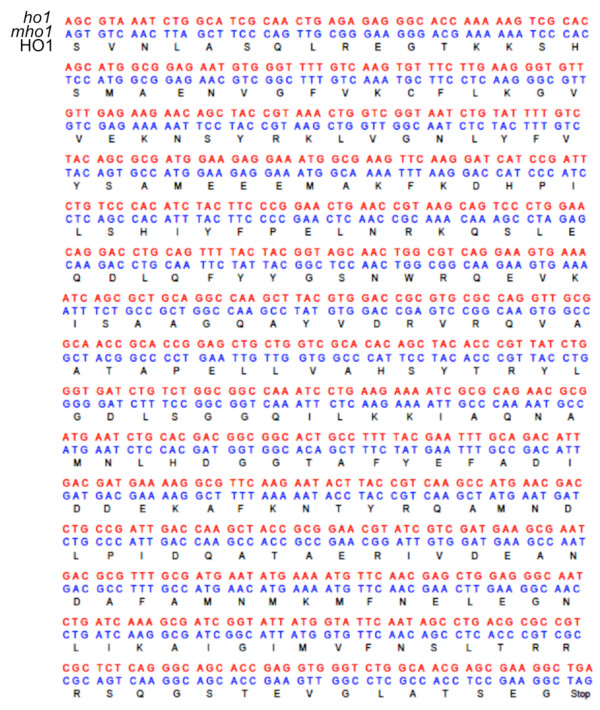


In [ ]:
co_ho1 = """AGT GTC AAC TTA GCT TCC CAG TTG CGG GAA GGG ACG AAA AAA TCC CAC
TCC ATG GCG GAG AAC GTC GGC TTT GTC AAA TGC TTC CTC AAG GGC GTT
GTC GAG AAA AAT TCC TAC CGT AAG CTG GTT GGC AAT CTC TAC TTT GTC
TAC AGT GCC ATG GAA GAG GAA ATG GCA AAA TTT AAG GAC CAT CCC ATC
CTC AGC CAC ATT TAC TTC CCC GAA CTA AAC CGC AAA CAA AGC CTA GAG
CAA GAC CTG CAA TTC TAT TAC GGC TCC AAC TGG CGG CAA GAA GTG AAA
ATT TCT GCC GCT GGC CAA GCC TAT GTG GAC CGA GTC CGG CAA GTG GCC
GCT ACG GCC CCT GAA TTG TTG GTG GCC CAT TCC TAC ACC CGT TAC CTG
GGG GAT CTT TCC GGC GGT CAA ATT CTC AAG AAA ATT GCC CAA AAT GCC
ATG AAT CTC CAC GAT GGT GGC ACA GCT TTC TAT GAA TTT GCC GAC ATT
GAT GAC GAA AAG GCT TTT AAA AAT ACC TAC CGT CAA GCT ATG AAT GAT
CTG CCC ATT GAC CAA GCC ACC GCC GAA CGG ATT GTG GAT GAA GCC AAT
GAC GCC TTT GCC ATG AAC ATG AAA ATG TTC AAC GAA CTT GAA GGC AAC
CTG ATC AAG GCG ATC GGC ATT ATG GTG TTC AAC AGC CTC ACC CGT CGC
CGC AGT CAA GGC AGC ACC GAA GTT GGC CTC GCC ACC TCC GAA GGC TAG""".replace(" ", "").replace("\n", "")

In [ ]:
ho1 = SeqRecord(Seq(co_ho1), id="ho1", name="ho1", description="Heme oxygenase 1 (Synechocystis PCC 6803)")
print(f"HO1: {len(ho1)} bp")
print(f"Translates to match: {ho1.seq.translate(to_stop=True) == Seq(ho1_aa)}")  # if you saved the AA seq

HO1: 720 bp
Translates to match: False


In [ ]:
ho1.translate()

SeqRecord(seq=Seq('SVNLASQLREGTKKSHSMAENVGFVKCFLKGVVEKNSYRKLVGNLYFVYSAMEE...EG*'), id='<unknown id>', name='<unknown name>', description='<unknown description>', dbxrefs=[])

Looks like it's missing a start that time?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yep! Your codon-optimized sequence starts with `AGT GTC AAC...` (S-V-N...) but it needs the `ATG` start codon at the front to give you the initial Methionine. It was probably on the figure but got missed in the OCR — if you look at the image, the first line likely has `ATG` before `AGT`.

Just prepend `ATG` to `co_ho1` and it should match.

It's not on the figure, they probably left it out to make a nice perfect rectangle

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Ha, that's a very plausible reason! So just add `ATG` at the start:

```python
co_ho1 = "ATG" + co_ho1
```

Then re-check with your translate/match test and you should be good to go.

In [ ]:
ho1 = SeqRecord(Seq("ATG"+co_ho1), id="ho1", name="ho1", description="Heme oxygenase 1 (Synechocystis PCC 6803)")
print(f"HO1: {len(ho1)} bp")
print(f"Translates to match: {ho1.seq.translate(to_stop=True) == Seq(ho1_aa)}")  # if you saved the AA seq

HO1: 723 bp
Translates to match: True


## Assembly

Hey you read that paper right. Given that, think our vector/approach is likely to work?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Let me take a look at that paper to give you a proper answer.

<details class='tool-usage-details'>
<summary>read_url(url='https://pmc.ncbi.nlm.nih.gov/articles/PMC3534565/')</summary>

```json
{
  "id": "toolu_01LXhzWRc7bqtXEZ8hbKiXPt",
  "call": {
    "function": "read_url",
    "arguments": {
      "url": "https://pmc.ncbi.nlm.nih.gov/articles/PMC3534565/"
    }
  },
  "result": "<TRUNCATED>\u2026in content \n\n![](https://cdn.ncbi.nlm.nih.gov/pmc/pd-medc-pmc-cloudpmc-viewer/production/a2b04810/var/data/static/img/us_flag.svg)\n\nAn official website of the United States government \n\nHere's how you know\n\nHere's how you know\n\n![](https://cdn.ncbi.nlm.nih.gov/pmc/pd-medc-pmc-cloudpmc-viewer/production/a2b04810/var/data/static/img/icon-dot-gov.svg)\n\n**Official websites use .gov**   \nA **.gov** website belongs to an official government organization in the United States. \n\n![](https://cdn.ncbi.nlm.nih.gov/pmc/pd-medc-pmc-cloudpmc-viewer/production/a2b04810/var/data/static/img/icon-https.svg)\n\n**Secure .gov websites use HTTPS**   \nA **lock** (  Lock Locked padlock icon  ) or **https://** means you've safely connected to the .gov website. Share sensitive information only on official, secure websites. \n\n[ ![NCBI home page](https://cdn.ncbi.nlm.nih.gov/pmc/pd-medc-pmc-cloudpmc-viewer/production/a2b04810/var/data/static/img/ncbi-logos/nih-nlm-ncbi--white.svg) ](https://www\u2026</TRUNCATED>"
}
```

</details>



🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

OK, having read through Chen et al. (2012), I think your approach is very likely to work for getting visible green, but there are some interesting differences worth noting:

**What the paper validates for you:**
- The core concept absolutely works — *E. coli* expressing the Synechocystis ho1 produces biliverdin and turns visibly green. That green material accumulated even in the foam above their cultures.
- Codon optimization gave them ~2x more biliverdin (BL21(mHO1) vs BL21(HO1)), so your plan to codon-optimize is well-supported.
- They did **not** supplement with 5-ALA or iron — they relied on the endogenous heme pool. That's encouraging.

**Key differences to think about:**
- They used **inducible** T7/T5 promoters on **high-copy** vectors (pET101, pJexpress401) in BL21(DE3), whereas you're going constitutive + medium-copy. You'll get substantially lower expression — but for a "visibly green colony" goal rather than mg/L production, that's arguably a *feature*, not a bug. Less drain on heme, healthier cells.
- Their best yields came with lactose as carbon source (auto-induction, no IPTG needed) — that won't apply to your constitutive setup, but it's useful to know if you ever pivot to an inducible design.

**One thing I'd watch**: with J23104 on p15A, you might be in a sweet spot, or you might be on the low side for visible color on plates. If you don't see green, bumping to a slightly stronger Anderson promoter (J23100 or J23106) would be the first thing to try.

Overall — yes, I think this will work. The biology is sound and well-validated by this paper.

OK let's stack them all together (terminator in front too) and check it as best we can, to get a final sequence I need to send off. Make sure we include a stop, add as many checks as you can.

In [ ]:
from Bio.SeqUtils import gc_fraction
import re

# 6 bp spacer (standard BioBrick scar spacing for B0034)
spacer = Seq("tactag")

# Assemble: 5'-[B0015]-[J23104]-[B0034]-[spacer]-[ho1]-[B0015]-3'
cassette = B0015.seq + promoter.seq + RBS.seq + spacer + ho1.seq + B0015.seq
cds = ho1.seq

print("=== Cassette Layout ===")
parts = [("B0015 insulator", B0015), ("J23104 promoter", promoter),
         ("B0034 RBS", RBS), ("Spacer", spacer), ("ho1 CDS", ho1), ("B0015 terminator", B0015)]
pos = 0
for name, p in parts:
    ln = len(p)
    print(f"  {pos+1:>4}–{pos+ln:>4}  {name} ({ln} bp)")
    pos += ln
print(f"  {'─'*40}")
print(f"  Total: {len(cassette)} bp")

# === CDS Checks ===
print("\n=== CDS Checks ===")
print(f"  Starts with ATG:         {str(cds[:3]).upper() == 'ATG'}")
print(f"  Length divisible by 3:   {len(cds) % 3 == 0} ({len(cds)} bp → {len(cds)//3} codons)")
stop = str(cds[-3:]).upper()
print(f"  Ends with stop codon:    {stop in ('TAA','TAG','TGA')} ({stop})")
protein = cds.translate(to_stop=True)
print(f"  Translation matches AA:  {str(protein) == ho1_aa} ({len(protein)} aa)")
internal_stops = str(cds[:-3].translate()).count('*')
print(f"  No internal stops:       {internal_stops == 0} ({internal_stops} found)")

# === Composition ===
print("\n=== Composition ===")
print(f"  GC% cassette: {gc_fraction(cassette):.1%}")
print(f"  GC% CDS:      {gc_fraction(cds):.1%}")

# === Restriction sites (both strands) ===
print("\n=== Restriction Sites ===")
cup = str(cassette).upper()
cup_rc = str(cassette.reverse_complement()).upper()
for name, site in [('EcoRI','GAATTC'), ('XbaI','TCTAGA'), ('SpeI','ACTAGT'),
                   ('PstI','CTGCAG'), ('BsaI','GGTCTC'), ('BpiI','GAAGAC'), ('NotI','GCGGCCGC')]:
    n = cup.count(site) + cup_rc.count(site)
    print(f"  {'⚠️' if n else '✓':>2} {name:6} ({site}): {n}")

# === Homopolymer runs ≥7 ===
print("\n=== Homopolymer Runs (≥7 bp) ===")
any_runs = False
for base in 'ACGT':
    runs = [m for m in re.finditer(f'{base}{{7,}}', cup)]
    if runs:
        any_runs = True
        for m in runs:
            print(f"  ⚠️ {base}×{m.end()-m.start()} at position {m.start()+1}")
if not any_runs:
    print("  ✓ None found")

# === RBS-to-ATG spacing ===
rbs_end = len(B0015) + len(promoter) + len(RBS)
atg_pos = rbs_end + len(spacer)
print(f"\n=== RBS→ATG Spacing ===")
print(f"  Spacer: {str(spacer)} ({len(spacer)} bp)")
print(f"  Context: ...{str(cassette[rbs_end-4:atg_pos+6]).upper()}...")

print(f"\n=== Full Sequence ({len(cassette)} bp) ===")
print(str(cassette))

=== Cassette Layout ===
     1– 129  B0015 insulator (129 bp)
   130– 164  J23104 promoter (35 bp)
   165– 176  B0034 RBS (12 bp)
   177– 182  Spacer (6 bp)
   183– 905  ho1 CDS (723 bp)
   906–1034  B0015 terminator (129 bp)
  ────────────────────────────────────────
  Total: 1034 bp

=== CDS Checks ===
  Starts with ATG:         True
  Length divisible by 3:   True (723 bp → 241 codons)
  Ends with stop codon:    True (TAG)
  Translation matches AA:  True (240 aa)
  No internal stops:       True (0 found)

=== Composition ===
  GC% cassette: 49.4%
  GC% CDS:      50.3%

=== Restriction Sites ===
   ✓ EcoRI  (GAATTC): 0
   ✓ XbaI   (TCTAGA): 0
   ✓ SpeI   (ACTAGT): 0
   ✓ PstI   (CTGCAG): 0
   ✓ BsaI   (GGTCTC): 0
   ✓ BpiI   (GAAGAC): 0
   ✓ NotI   (GCGGCCGC): 0

=== Homopolymer Runs (≥7 bp) ===
  ✓ None found

=== RBS→ATG Spacing ===
  Spacer: tactag (6 bp)
  Context: ...GAAATACTAGATGAGT...

=== Full Sequence (1034 bp) ===
ccaggcatcaaataaaacgaaaggctcagtcgaaagactgggcctttcgttttatctgtt

In [ ]:
str(cassette)

'ccaggcatcaaataaaacgaaaggctcagtcgaaagactgggcctttcgttttatctgttgtttgtcggtgaacgctctctactagagtcacactggctcaccttcgggtgggcctttctgcgtttatattgacagctagctcagtcctaggtattgtgctagcaaagaggagaaatactagATGAGTGTCAACTTAGCTTCCCAGTTGCGGGAAGGGACGAAAAAATCCCACTCCATGGCGGAGAACGTCGGCTTTGTCAAATGCTTCCTCAAGGGCGTTGTCGAGAAAAATTCCTACCGTAAGCTGGTTGGCAATCTCTACTTTGTCTACAGTGCCATGGAAGAGGAAATGGCAAAATTTAAGGACCATCCCATCCTCAGCCACATTTACTTCCCCGAACTAAACCGCAAACAAAGCCTAGAGCAAGACCTGCAATTCTATTACGGCTCCAACTGGCGGCAAGAAGTGAAAATTTCTGCCGCTGGCCAAGCCTATGTGGACCGAGTCCGGCAAGTGGCCGCTACGGCCCCTGAATTGTTGGTGGCCCATTCCTACACCCGTTACCTGGGGGATCTTTCCGGCGGTCAAATTCTCAAGAAAATTGCCCAAAATGCCATGAATCTCCACGATGGTGGCACAGCTTTCTATGAATTTGCCGACATTGATGACGAAAAGGCTTTTAAAAATACCTACCGTCAAGCTATGAATGATCTGCCCATTGACCAAGCCACCGCCGAACGGATTGTGGATGAAGCCAATGACGCCTTTGCCATGAACATGAAAATGTTCAACGAACTTGAAGGCAACCTGATCAAGGCGATCGGCATTATGGTGTTCAACAGCCTCACCCGTCGCCGCAGTCAAGGCAGCACCGAAGTTGGCCTCGCCACCTCCGAAGGCTAGccaggcatcaaataaaacgaaaggctcagtcgaaagactgggcctttcgttttatctgttgtttgtcggtgaacgctctctactagagtcacac